# Plot features of load-selective neurons



In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-06-25 16:44:41.174587: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-25 16:44:41.183174: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-25 16:44:41.193409: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-25 16:44:41.196468: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-25 16:44:41.205362: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# the 11 models with > 0.7 accuracy are:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [4]:
# find folder names within model directory

perfs = []
for i, model_name in enumerate(model_names):
    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    load1_idx = np.where(trial_labels[:,0] == 1)[0]
    load2_idx = np.where(trial_labels[:,0] == 2)[0]
    load3_idx = np.where(trial_labels[:,0] == 3)[0]
    perfs.append([np.mean(trial_perfs[load1_idx]), np.mean(trial_perfs[load2_idx]), np.mean(trial_perfs[load3_idx])])
    print(f'Model {model_name}, performance: {perfs[i]}')


Model Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901, performance: [0.425, nan, 0.4166666666666667]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721, performance: [0.89, 0.73, 0.7]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000, performance: [0.97, 0.84, 0.75]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152, performance: [0.9, 0.92, 0.81]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002, performance: [0.96, 0.78, 0.7]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744, performance: [0.96, 0.86, 0.73]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239, performance: [0.97, 0.83, 0.72]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128, performance: [0.95, 0.83, 0.79]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128, performance: [0.95, 0.83, 0.74]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647, performance: [0.82, 0.79, 0.7]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131, performance: [0.99, 0.8, 0.71]


/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Load-selectivity

Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...


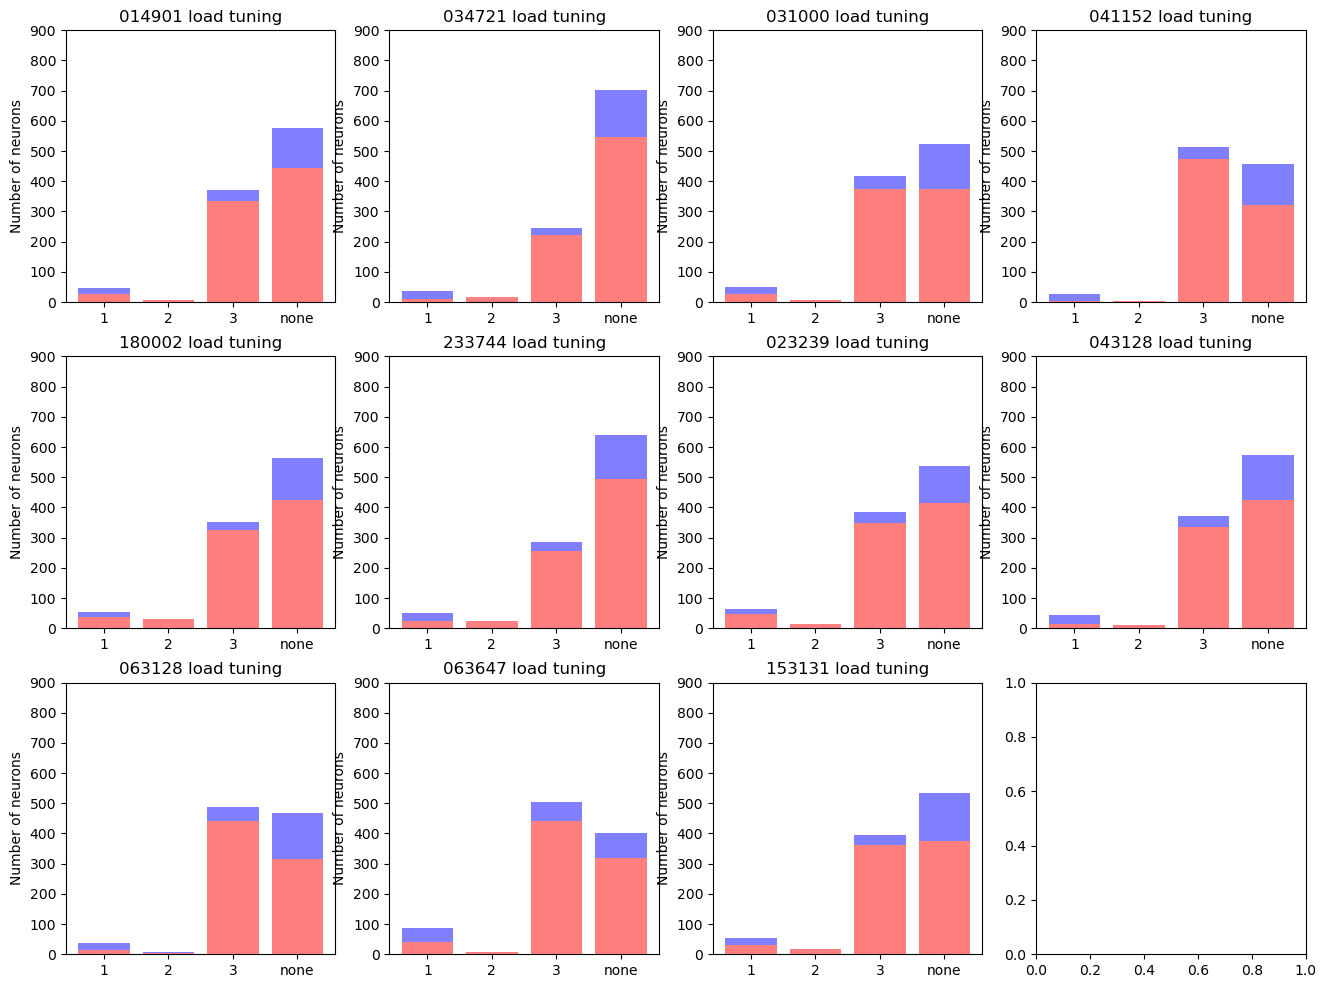

In [9]:
importlib.reload(rn)

fig, axs = plt.subplots(3, 4, figsize=(16,12))
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    rn.plot_load_tuning(tuning, tuning_options = [1, 2, 3, np.nan], exc_ind=exc_ind, title=f'{model_name[-6:]} load tuning', ax=axs[i])
    axs[i].set_xlabel('')
    axs[i].set_ylim([0, 900])

### load-selective within stim1-selection

Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...


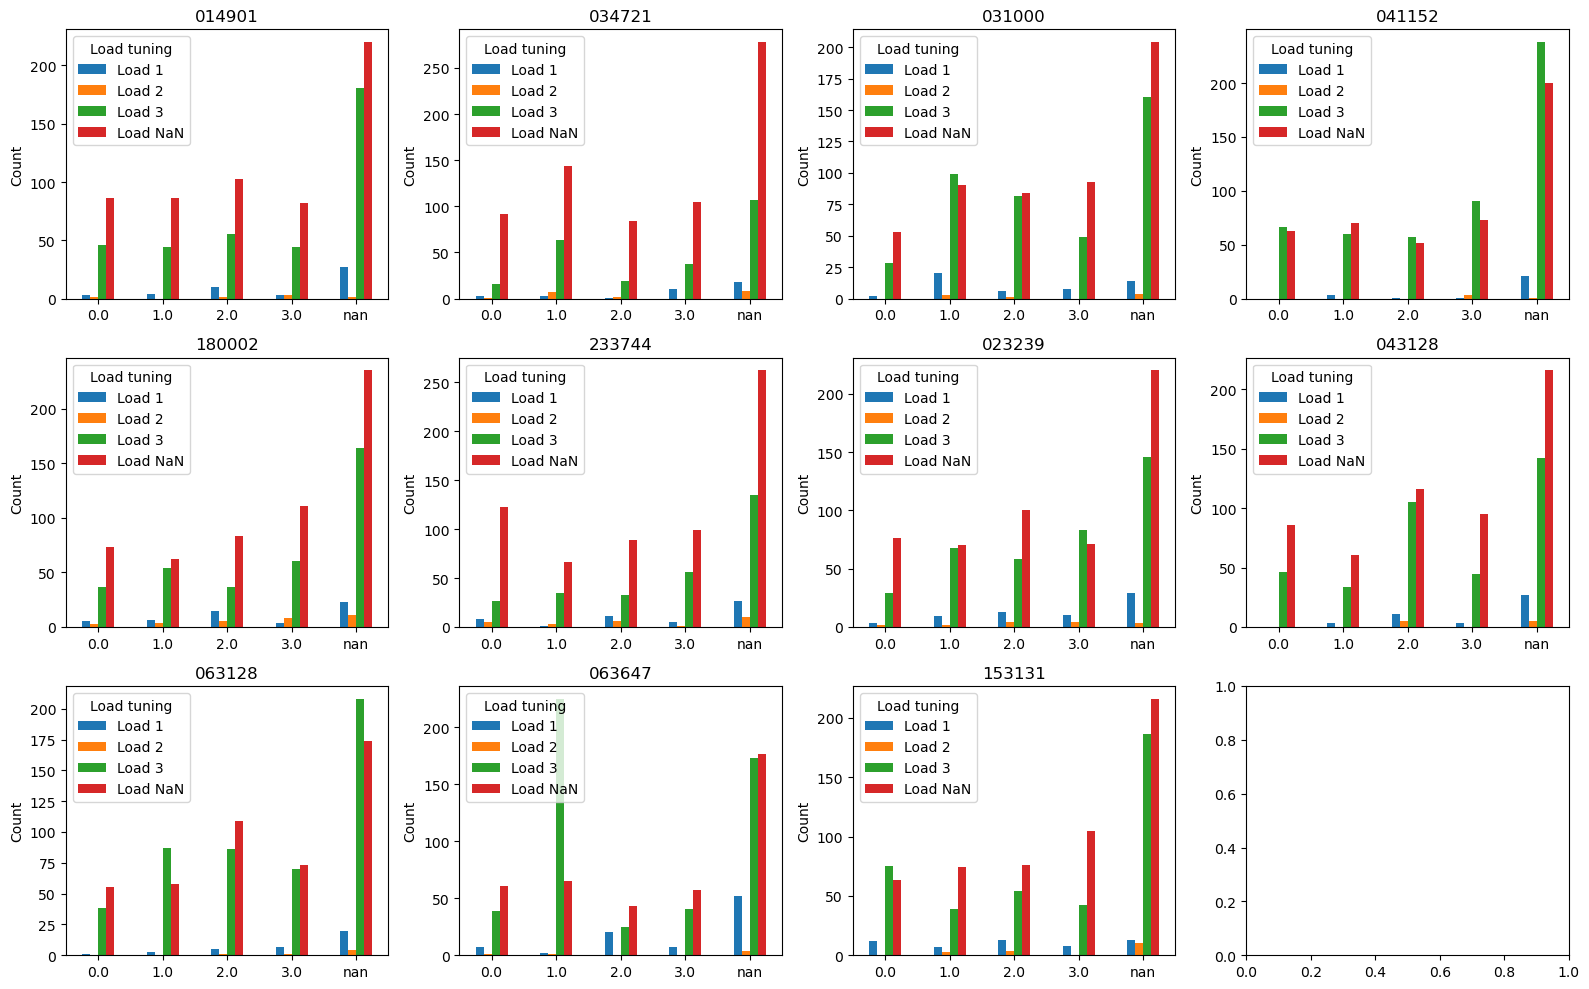

In [17]:
# all models

import pandas as pd

fig, ax = plt.subplots(3, 4, figsize=(16,10))
ax = ax.flatten()
for i, model_name in enumerate(model_names):
    model_dir = os.path.join(all_models_dir, model_name)

    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels= "balance_stims",
                                all_models_dir=all_models_dir)

    stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']

    # build database for each neuron and its tuning
    neuron_db = []
    for neuron_idx in range(load_tuning.shape[0]):
        neuron_info = {'load_tuning': load_tuning[neuron_idx],
                    'stim1_tuning': stim1_tuning[neuron_idx]}
        neuron_db.append(neuron_info)
        
    neuron_db = pd.DataFrame(neuron_db)
    neuron_db['tuning_combination'] = neuron_db.apply(lambda row: f"load{row['load_tuning']}_stim{row['stim1_tuning']}", axis=1)
    tuning_counts = neuron_db['tuning_combination'].value_counts()

    # Recreate counts as a DataFrame
    df_counts = tuning_counts.rename_axis('combination').reset_index(name='count')

    # Extract load and stim values from strings
    df_counts[['load', 'stim']] = df_counts['combination'].str.extract(r'load(.*?)_stim(.*)')

    # Convert to numeric (keep NaN properly)
    df_counts['load'] = pd.to_numeric(df_counts['load'], errors='coerce')
    df_counts['stim'] = pd.to_numeric(df_counts['stim'], errors='coerce')

    # Pivot so rows = stim, columns = load
    pivot = df_counts.pivot(index='stim', columns='load', values='count')

    # Reindex to enforce order
    pivot = pivot.reindex(index=[0,1,2,3,np.nan], columns=[1,2,3,np.nan])

    # Plot
    pivot.plot(kind='bar', ax=ax[i])

    # ax[i].set_xlabel('Stim1 tuning')
    ax[i].set_ylabel('Count')
    ax[i].set_xlabel('')
    ax[i].set_title(f'{model_name[-6:]}')
    ax[i].legend(title='Load tuning', labels=['Load 1', 'Load 2', 'Load 3', 'Load NaN'])
    # turn tick labels into flat orietation
    ax[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Check features of load-selective neurons

### excitatory / inhibitory

In [6]:
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

# look for load-tuned and stim-untuned neurons
load_tuned = np.where(~np.isnan(tuning))[0]
stim_untuned = np.where(np.isnan(stim1_tuning))[0]
neuron_idxs = np.intersect1d(load_tuned, stim_untuned)
print(f'Number of load-tuned, stim-untuned neurons: {len(neuron_idxs)}')

load1_tuned = np.where(tuning[neuron_idxs] == 1)[0]
load3_tuned = np.where(tuning[neuron_idxs] == 3)[0]
print(f'Number of load-tuned, stim-untuned neurons that are load1-tuned: {len(load1_tuned)}')
print(f'Number of load-tuned, stim-untuned neurons that are load3-tuned: {len(load3_tuned)}')

print(f'Number of load-1 exc: {len(np.intersect1d(load1_tuned, exc_ind))}')
print(f'Number of load-1 inh: {len(np.intersect1d(load1_tuned, inh_ind))}')
print(f'Number of load-3 exc: {len(np.intersect1d(load3_tuned, exc_ind))}')
print(f'Number of load-3 inh: {len(np.intersect1d(load3_tuned, inh_ind))}')

Loading behavioral data...
Number of load-tuned, stim-untuned neurons: 209
Number of load-tuned, stim-untuned neurons that are load1-tuned: 27
Number of load-tuned, stim-untuned neurons that are load3-tuned: 181
Number of load-1 exc: 19
Number of load-1 inh: 8
Number of load-3 exc: 154
Number of load-3 inh: 27


Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...


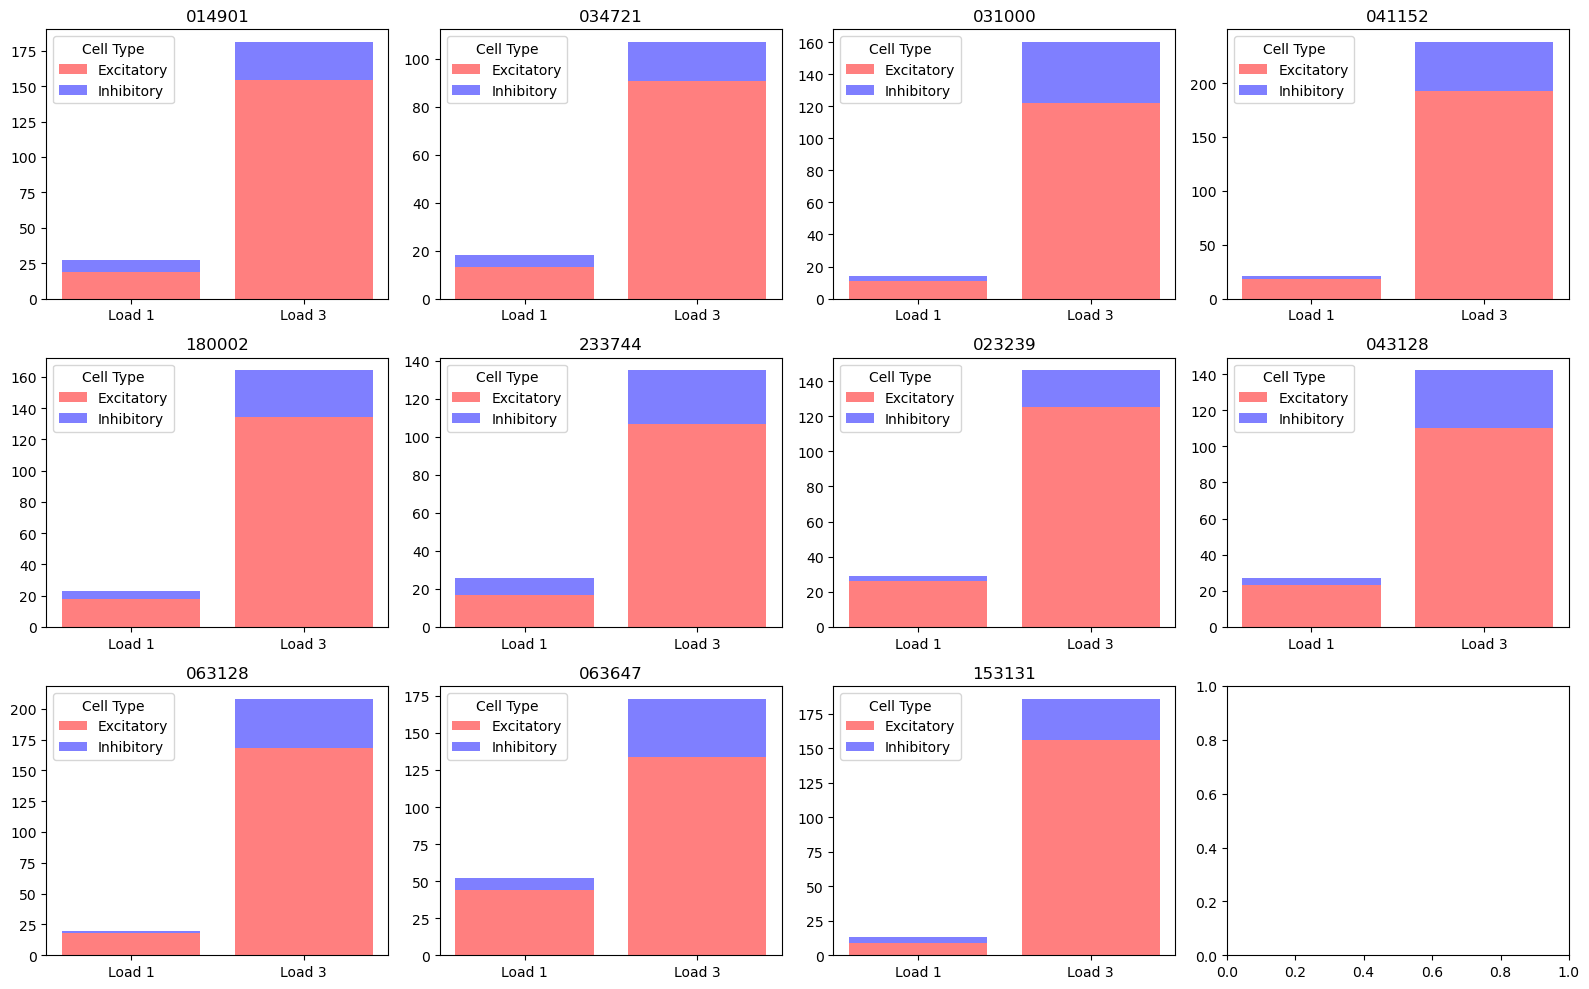

In [12]:
fig, ax = plt.subplots(3, 4, figsize=(16,10))
axs = ax.flatten()
for i, model_name in enumerate(model_names):
    model_dir = os.path.join(all_models_dir, model_name)
    
    tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    # look for load-tuned and stim-untuned neurons
    load_tuned = np.where(~np.isnan(tuning))[0]
    stim_untuned = np.where(np.isnan(stim1_tuning))[0]
    neuron_idxs = np.intersect1d(load_tuned, stim_untuned)

    load1_tuned = np.where(tuning[neuron_idxs] == 1)[0]
    load3_tuned = np.where(tuning[neuron_idxs] == 3)[0]
    
    # stack bar plot of load1 and load3 tuned neurons, split by exc and inh
    axs[i].bar(1, len(np.intersect1d(load1_tuned, exc_ind)), color='red', label='Load 1 Exc', alpha=0.5)
    axs[i].bar(1, len(np.intersect1d(load1_tuned, inh_ind)), color='blue', label='Load 1 Inh', bottom=len(np.intersect1d(load1_tuned, exc_ind)), alpha=0.5)
    axs[i].bar(2, len(np.intersect1d(load3_tuned, exc_ind)), color='red', label='Load 3 Exc', alpha=0.5)
    axs[i].bar(2, len(np.intersect1d(load3_tuned, inh_ind)), color='blue', label='Load 3 Inh', bottom=len(np.intersect1d(load3_tuned, exc_ind)), alpha=0.5)
    
    axs[i].set_title(f'{model_name[-6:]}')
    axs[i].legend(title='Cell Type', labels=['Excitatory', 'Inhibitory'])
    axs[i].set_xticks([1, 2], labels=['Load 1', 'Load 3'])
    
plt.tight_layout()
plt.show()

In [ ]:
load1_exc_percs = []
load1_inh_percs = []
load3_exc_percs = []
load3_inh_percs = []

for i, model_name in enumerate(model_names):
    model_dir = os.path.join(all_models_dir, model_name)
    
    tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    # look for load-tuned and stim-untuned neurons
    load_tuned = np.where(~np.isnan(tuning))[0]
    stim_untuned = np.where(np.isnan(stim1_tuning))[0]
    neuron_idxs = np.intersect1d(load_tuned, stim_untuned)

    load1_tuned = np.where(tuning[neuron_idxs] == 1)[0]
    load3_tuned = np.where(tuning[neuron_idxs] == 3)[0]
    
    # calculate percentages
    load1_exc = len(np.intersect1d(load1_tuned, exc_ind)) / len(exc_ind)
    load1_inh = len(np.intersect1d(load1_tuned, inh_ind)) / len(inh_ind)
    load3_exc = len(np.intersect1d(load3_tuned, exc_ind)) / len(exc_ind)
    load3_inh = len(np.intersect1d(load3_tuned, inh_ind)) / len(inh_ind)
    
    load1_exc_percs.append(load1_exc)
    load1_inh_percs.append(load1_inh)
    load3_exc_percs.append(load3_exc)
    load3_inh_percs.append(load3_inh)
    

/tmp/ipykernel_717548/2669493054.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([load1_exc_percs, load1_inh_percs, load3_exc_percs, load3_inh_percs],


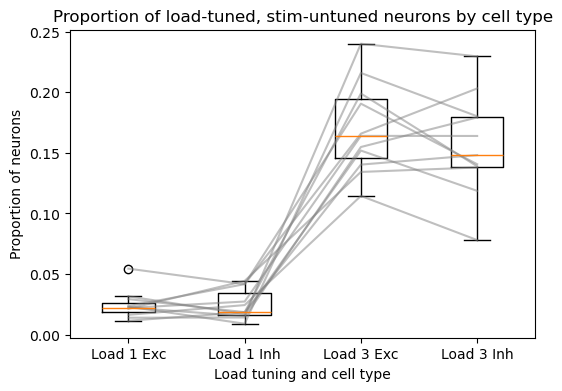

In [15]:
plt.figure(figsize=(6,4))
plt.boxplot([load1_exc_percs, load1_inh_percs, load3_exc_percs, load3_inh_percs],
            labels=['Load 1 Exc', 'Load 1 Inh', 'Load 3 Exc', 'Load 3 Inh'])
# plot gray lines connecting load1 and load3 for each model
for i in range(len(model_names)):
    plt.plot([1, 2, 3, 4], [load1_exc_percs[i], load1_inh_percs[i], load3_exc_percs[i], load3_inh_percs[i]], color='gray', alpha=0.5)
plt.xlabel('Load tuning and cell type')
plt.ylabel('Proportion of neurons') 
plt.title('Proportion of load-tuned, stim-untuned neurons by cell type')
plt.show()

### timescales

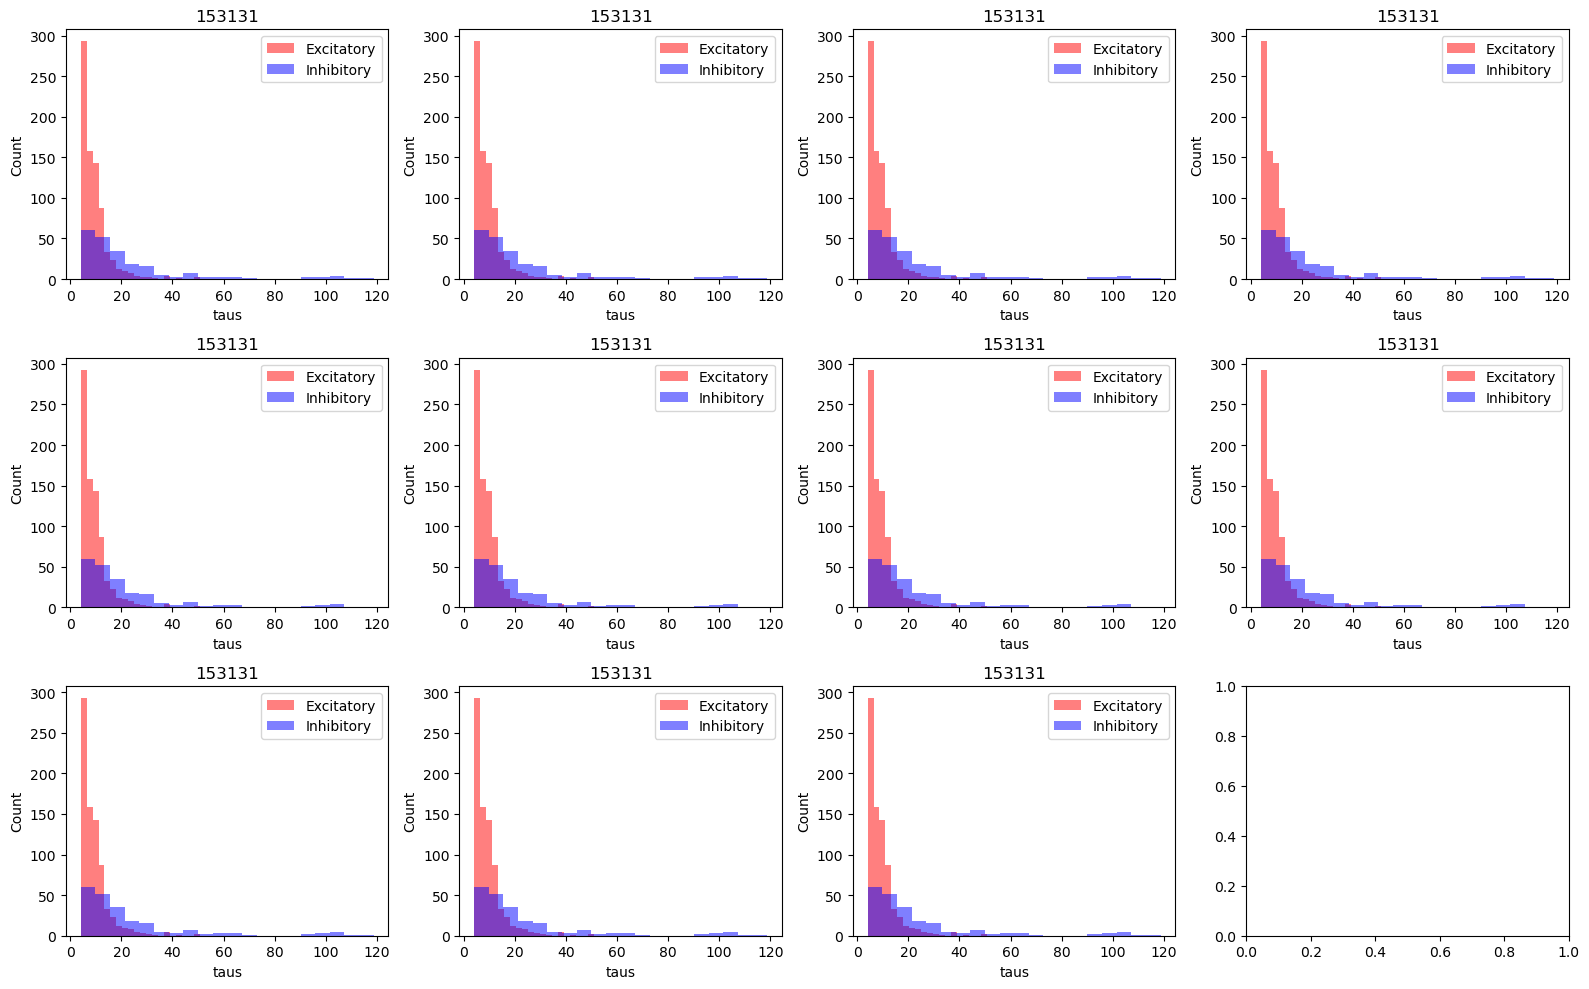

In [21]:
# first just check if exc/inh timescales are different

fig, axs = plt.subplots(3, 4, figsize=(16,10))
axs = axs.flatten()
for i, model_fname in enumerate(model_names):
    mat_data = scipy.io.loadmat(os.path.join(all_models_dir, model_name))
    
    # taus
    taus_gaus = mat_data['taus_gaus'].squeeze()
    taus = mat_data['taus'].squeeze()
    taus_sig = 1 / (1 + np.exp(-taus_gaus)) * (taus[1] - taus[0]) + taus[0]
    
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
    
    axs[i].hist(taus_sig[exc_ind], bins=20, alpha=0.5, color='red', label='Excitatory')
    axs[i].hist(taus_sig[inh_ind], bins=20, alpha=0.5, color='blue', label='Inhibitory')
    axs[i].set_title(f'{model_name[-6:]}')
    axs[i].set_xlabel('taus')
    axs[i].set_ylabel('Count')
    axs[i].legend()
plt.tight_layout()
plt.show()

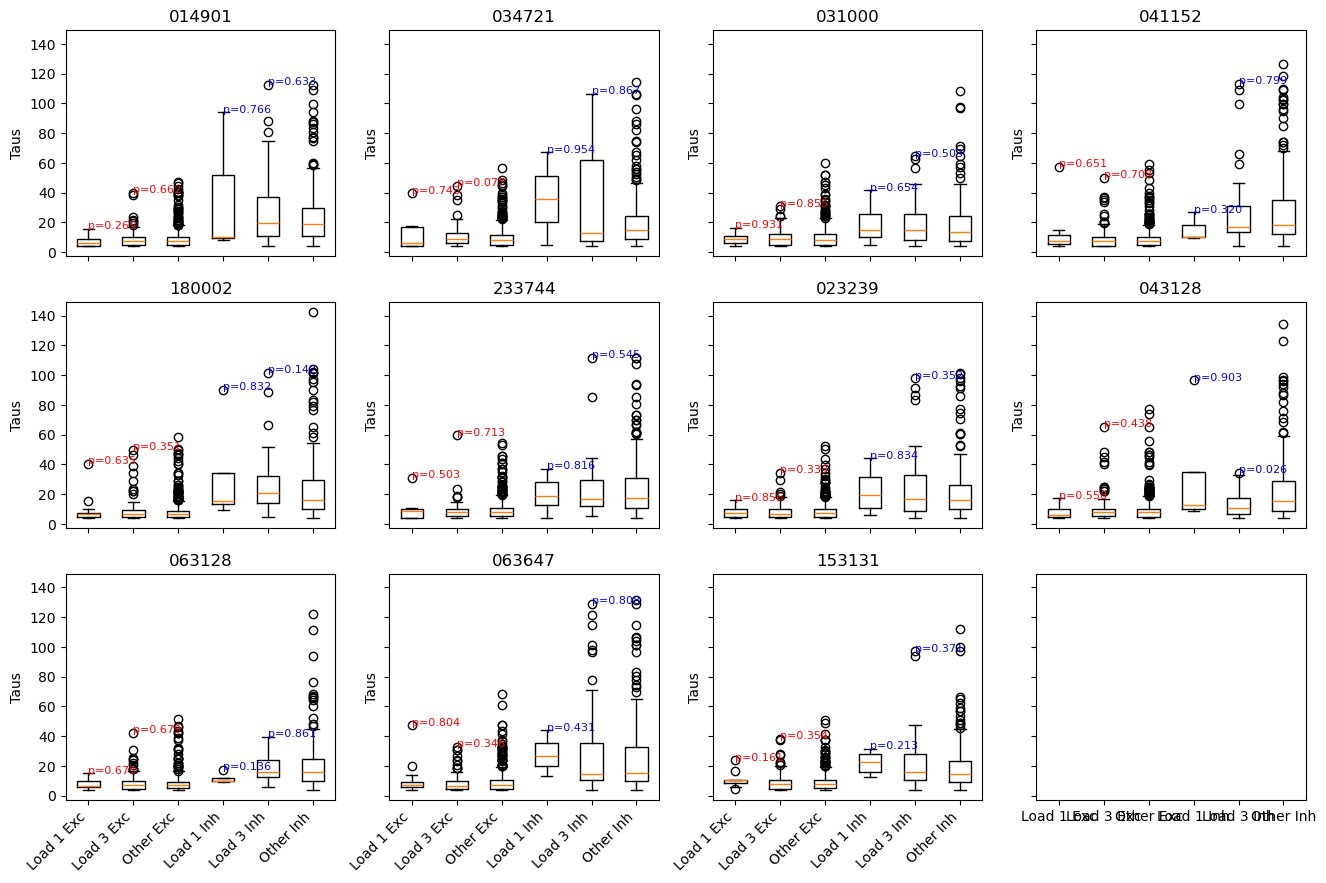

In [29]:
importlib.reload(rn)
fig, axs = plt.subplots(3, 4, figsize=(16,10), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    mat_data = scipy.io.loadmat(os.path.join(all_models_dir, model_name))
    
    # taus
    taus_gaus = mat_data['taus_gaus'].squeeze()
    taus = mat_data['taus'].squeeze()
    taus_sig = 1 / (1 + np.exp(-taus_gaus)) * (taus[1] - taus[0]) + taus[0]

    # tuning
    tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    # look for load-tuned and stim-untuned neurons
    load_tuned = np.where(~np.isnan(tuning))[0]
    stim_untuned = np.where(np.isnan(stim1_tuning))[0]
    neuron_idxs = np.intersect1d(load_tuned, stim_untuned)

    load1_tuned = np.where(tuning[neuron_idxs] == 1)[0]
    load3_tuned = np.where(tuning[neuron_idxs] == 3)[0]
    
    load1_exc = np.intersect1d(load1_tuned, exc_ind)
    load1_inh = np.intersect1d(load1_tuned, inh_ind)
    load3_exc = np.intersect1d(load3_tuned, exc_ind)
    load3_inh = np.intersect1d(load3_tuned, inh_ind)
    
    axs[i].boxplot([taus_sig[load1_exc], taus_sig[load3_exc], taus_sig[np.setdiff1d(exc_ind, neuron_idxs)], # excitatory but not load-tuned, stim-untuned 
                    taus_sig[load1_inh], taus_sig[load3_inh], taus_sig[np.setdiff1d(inh_ind, neuron_idxs)]],)
    
    # run stats, Mann-Whitney
    from scipy.stats import mannwhitneyu
    # Excitatory
    stat_exc, p_exc = mannwhitneyu(taus_sig[load1_exc], taus_sig[np.setdiff1d(exc_ind, neuron_idxs)])
    stat_exc2, p_exc2 = mannwhitneyu(taus_sig[load3_exc], taus_sig[np.setdiff1d(exc_ind, neuron_idxs)])
    # Inhibitory
    stat_inh, p_inh = mannwhitneyu(taus_sig[load1_inh], taus_sig[np.setdiff1d(inh_ind, neuron_idxs)])
    stat_inh2, p_inh2 = mannwhitneyu(taus_sig[load3_inh], taus_sig[np.setdiff1d(inh_ind, neuron_idxs)])
    
    # if p_exc < 0.05:
    axs[i].text(1, np.max(taus_sig[load1_exc]), f'p={p_exc:.3f}', color='red', fontsize=8)
    # if p_exc2 < 0.05:
    axs[i].text(2, np.max(taus_sig[load3_exc]), f'p={p_exc2:.3f}', color='red', fontsize=8)
    # if p_inh < 0.05:
    axs[i].text(4, np.max(taus_sig[load1_inh]), f'p={p_inh:.3f}', color='blue', fontsize=8)
    # if p_inh2 < 0.05:
    axs[i].text(5, np.max(taus_sig[load3_inh]), f'p={p_inh2:.3f}', color='blue', fontsize=8)
    
    
    axs[i].set_xticks(np.arange(1, 7))
    axs[i].set_xticklabels(['Load 1 Exc', 'Load 3 Exc', 'Other Exc', 'Load 1 Inh', 'Load 3 Inh', 'Other Inh'], rotation=45, ha='right')
    axs[i].set_ylabel('Taus')
    axs[i].set_title(f'{model_name[-6:]}')
    


### presynaptic connections

In [11]:
import connectivity_utils as cu
importlib.reload(ld)

# For each model, count exc/inh presynaptic (upstream) connections split by the
# target neuron's own cell type (exc/inh).
# W[a, b]: b -> a, so W[postsyn, presyn]; row = postsynaptic, col = presynaptic.
#
# Groups: load-1 exc, load-1 inh, load-3 exc, load-3 inh,
#         control exc (stim-untuned, not load-selective), control inh

presyn_counts = {g: {'exc': [], 'inh': []} for g in ['l1_exc', 'l1_inh', 'l3_exc', 'l3_inh', 'ctrl_exc', 'ctrl_inh']}

for i, model_name in enumerate(model_names):
    model_dir = os.path.join(all_models_dir, model_name)

    tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num,
                                           other_labels='balance_stims',
                                           all_models_dir=all_models_dir)
    stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    # W[postsyn, presyn]
    W = ld.get_weights(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)

    # actual neuron indices for load-tuned, stim-untuned neurons
    load_tuned   = np.where(~np.isnan(tuning))[0]
    stim_untuned = np.where(np.isnan(stim1_tuning))[0]
    neuron_idxs  = np.intersect1d(load_tuned, stim_untuned)

    # split load-selective neurons by own cell type
    load1_idxs = neuron_idxs[tuning[neuron_idxs] == 1]
    load3_idxs = neuron_idxs[tuning[neuron_idxs] == 3]

    load1_exc_idxs = np.intersect1d(load1_idxs, exc_ind)
    load1_inh_idxs = np.intersect1d(load1_idxs, inh_ind)
    load3_exc_idxs = np.intersect1d(load3_idxs, exc_ind)
    load3_inh_idxs = np.intersect1d(load3_idxs, inh_ind)

    # control: stim-untuned but NOT load-selective, split by cell type
    ctrl_idxs     = np.setdiff1d(stim_untuned, neuron_idxs)
    ctrl_exc_idxs = np.intersect1d(ctrl_idxs, exc_ind)
    ctrl_inh_idxs = np.intersect1d(ctrl_idxs, inh_ind)

    def count_upstream(target_idxs, W, source_idxs):
        if len(target_idxs) == 0:
            return np.array([])
        return np.sum(W[np.ix_(target_idxs, source_idxs)] != 0, axis=1)

    for key, idxs in [('l1_exc', load1_exc_idxs), ('l1_inh', load1_inh_idxs),
                      ('l3_exc', load3_exc_idxs), ('l3_inh', load3_inh_idxs),
                      ('ctrl_exc', ctrl_exc_idxs), ('ctrl_inh', ctrl_inh_idxs)]:
        presyn_counts[key]['exc'].append(count_upstream(idxs, W, exc_ind))
        presyn_counts[key]['inh'].append(count_upstream(idxs, W, inh_ind))

    print(f'{model_name[-6:]}: '
          f'L1 exc({len(load1_exc_idxs)}) presyn exc={np.mean(count_upstream(load1_exc_idxs, W, exc_ind)):.1f} inh={np.mean(count_upstream(load1_exc_idxs, W, inh_ind)):.1f} | '
          f'L1 inh({len(load1_inh_idxs)}) presyn exc={np.mean(count_upstream(load1_inh_idxs, W, exc_ind)):.1f} inh={np.mean(count_upstream(load1_inh_idxs, W, inh_ind)):.1f} | '
          f'L3 exc({len(load3_exc_idxs)}) presyn exc={np.mean(count_upstream(load3_exc_idxs, W, exc_ind)):.1f} inh={np.mean(count_upstream(load3_exc_idxs, W, inh_ind)):.1f} | '
          f'L3 inh({len(load3_inh_idxs)}) presyn exc={np.mean(count_upstream(load3_inh_idxs, W, exc_ind)):.1f} inh={np.mean(count_upstream(load3_inh_idxs, W, inh_ind)):.1f}')

014901: L1 exc(8) presyn exc=0.0 inh=34.8 | L1 inh(19) presyn exc=0.0 inh=22.7 | L3 exc(168) presyn exc=0.0 inh=36.3 | L3 inh(13) presyn exc=0.0 inh=19.6


/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


034721: L1 exc(0) presyn exc=nan inh=nan | L1 inh(18) presyn exc=0.0 inh=23.7 | L3 exc(96) presyn exc=0.0 inh=37.5 | L3 inh(11) presyn exc=0.0 inh=20.7
031000: L1 exc(2) presyn exc=0.0 inh=42.5 | L1 inh(12) presyn exc=0.0 inh=25.2 | L3 exc(142) presyn exc=0.0 inh=39.7 | L3 inh(18) presyn exc=0.0 inh=21.9
041152: L1 exc(2) presyn exc=0.0 inh=40.0 | L1 inh(19) presyn exc=0.0 inh=23.6 | L3 exc(220) presyn exc=0.0 inh=36.9 | L3 inh(18) presyn exc=0.0 inh=23.9
180002: L1 exc(11) presyn exc=0.0 inh=33.0 | L1 inh(12) presyn exc=0.0 inh=21.7 | L3 exc(154) presyn exc=0.0 inh=33.6 | L3 inh(10) presyn exc=0.0 inh=16.4
233744: L1 exc(9) presyn exc=0.0 inh=33.9 | L1 inh(17) presyn exc=1.1 inh=24.5 | L3 exc(118) presyn exc=0.0 inh=37.3 | L3 inh(17) presyn exc=0.0 inh=20.5
023239: L1 exc(17) presyn exc=0.0 inh=33.6 | L1 inh(12) presyn exc=0.0 inh=20.1 | L3 exc(134) presyn exc=0.0 inh=33.2 | L3 inh(12) presyn exc=0.0 inh=19.0
043128: L1 exc(6) presyn exc=0.0 inh=41.5 | L1 inh(21) presyn exc=2.0 inh=19

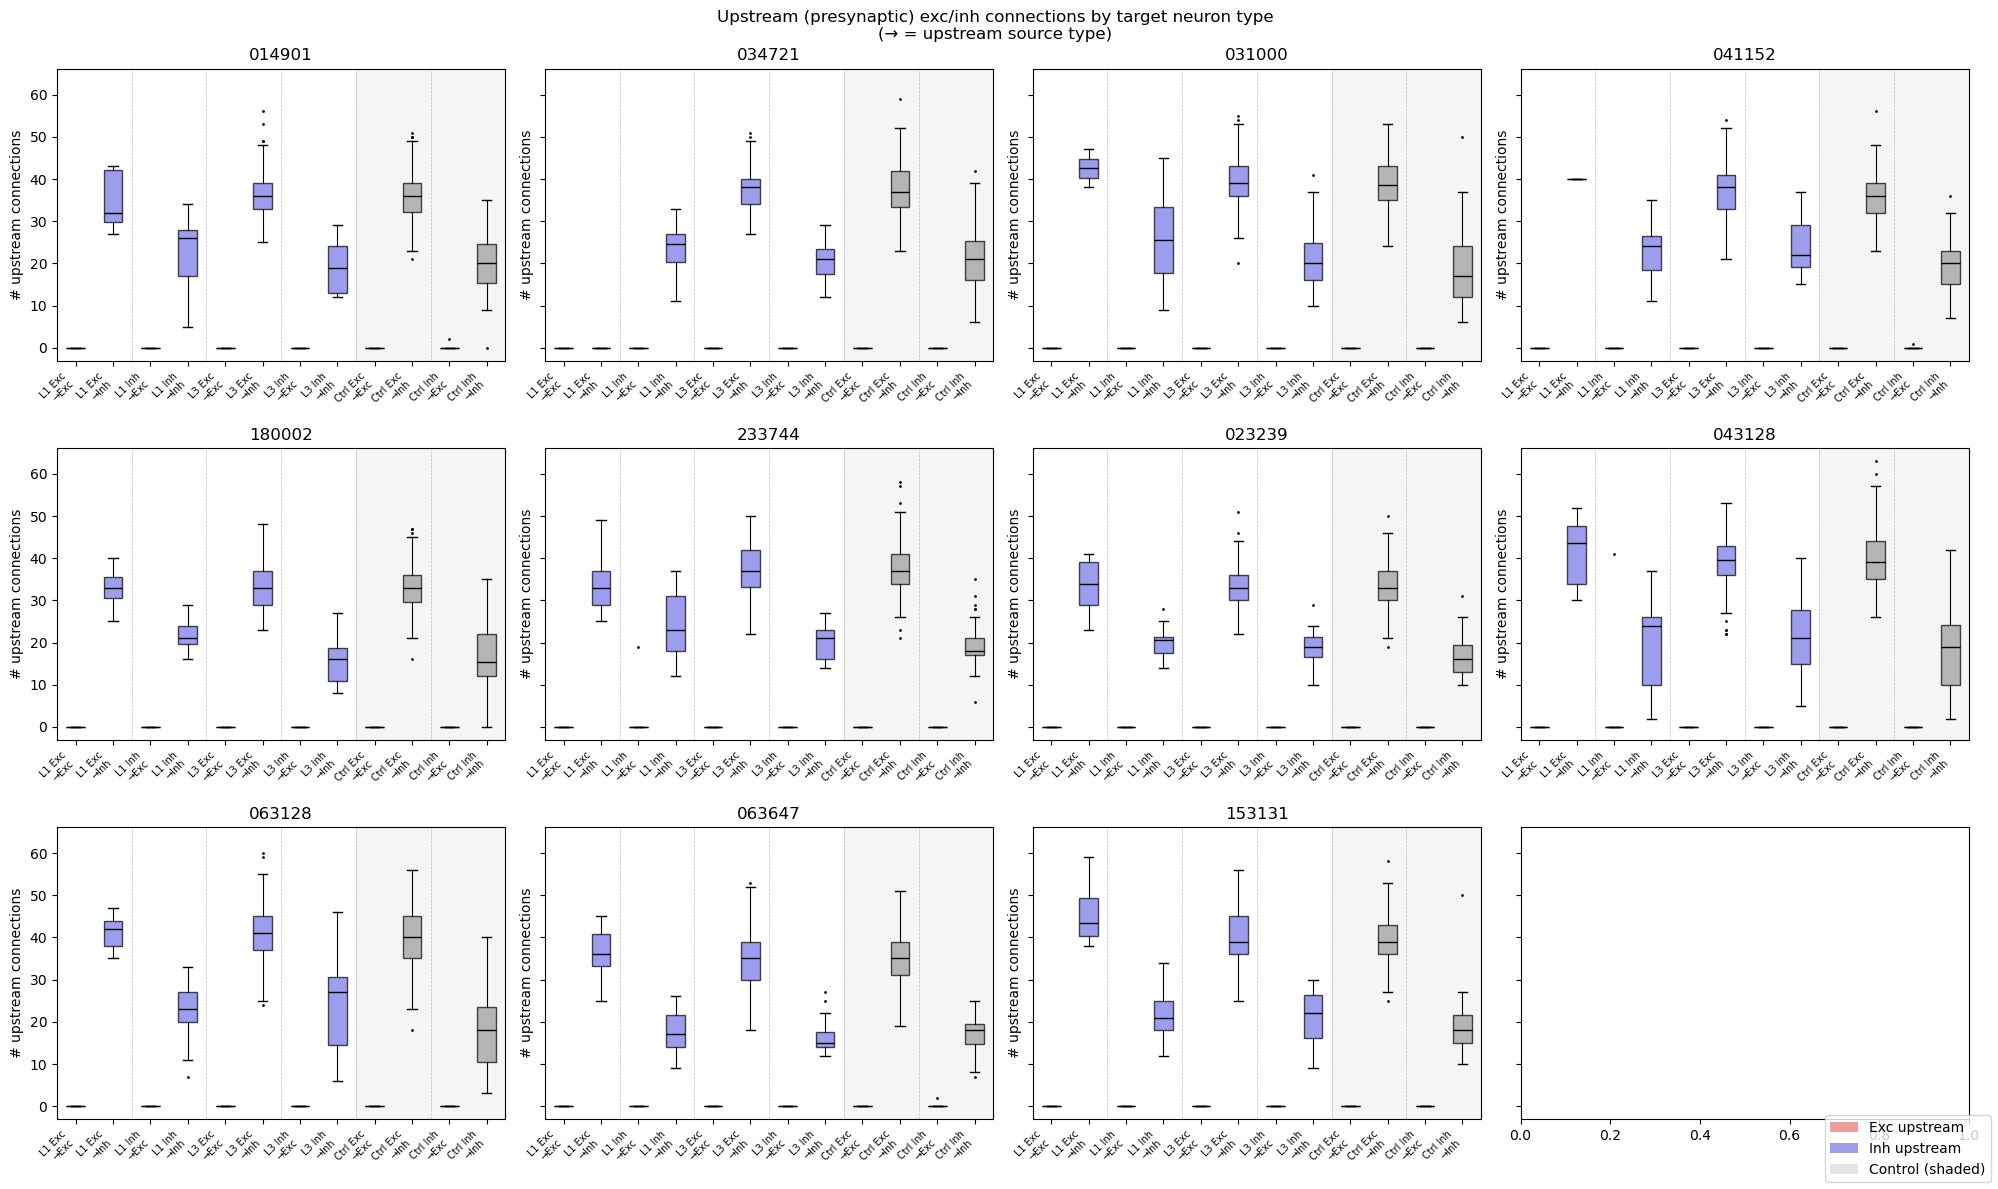

In [12]:
# Per-model boxplots: upstream exc/inh connections, split by target cell type
# x-axis: [L1-Exc→Exc, L1-Exc→Inh, L1-Inh→Exc, L1-Inh→Inh,
#           L3-Exc→Exc, L3-Exc→Inh, L3-Inh→Exc, L3-Inh→Inh,
#           Ctrl-Exc→Exc, Ctrl-Exc→Inh, Ctrl-Inh→Exc, Ctrl-Inh→Inh]

labels = ['L1 Exc\n→Exc', 'L1 Exc\n→Inh', 'L1 Inh\n→Exc', 'L1 Inh\n→Inh',
          'L3 Exc\n→Exc', 'L3 Exc\n→Inh', 'L3 Inh\n→Exc', 'L3 Inh\n→Inh',
          'Ctrl Exc\n→Exc', 'Ctrl Exc\n→Inh', 'Ctrl Inh\n→Exc', 'Ctrl Inh\n→Inh']
group_keys = [('l1_exc','exc'), ('l1_exc','inh'), ('l1_inh','exc'), ('l1_inh','inh'),
              ('l3_exc','exc'), ('l3_exc','inh'), ('l3_inh','exc'), ('l3_inh','inh'),
              ('ctrl_exc','exc'), ('ctrl_exc','inh'), ('ctrl_inh','exc'), ('ctrl_inh','inh')]
# colors: red=exc presyn, blue=inh presyn; opacity by group
box_colors = ['#e87474','#7474e8','#e87474','#7474e8',
              '#e87474','#7474e8','#e87474','#7474e8',
              '#999999','#999999','#999999','#999999']

fig, axs = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
axs = axs.flatten()

for i, model_name in enumerate(model_names):
    data = [presyn_counts[g][t][i] for g, t in group_keys]
    # filter out empty arrays (groups with 0 neurons)
    plot_data = [d if len(d) > 0 else np.array([0]) for d in data]
    
    bp = axs[i].boxplot(plot_data, positions=np.arange(1, 13), patch_artist=True,
                        medianprops=dict(color='black'), whiskerprops=dict(linewidth=0.8),
                        flierprops=dict(marker='.', markersize=2))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # vertical separators between groups
    for x in [2.5, 4.5, 6.5, 8.5, 10.5]:
        axs[i].axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    # shade control region
    axs[i].axvspan(8.5, 12.5, color='gray', alpha=0.08)

    axs[i].set_xticks(np.arange(1, 13))
    axs[i].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    axs[i].set_ylabel('# upstream connections')
    axs[i].set_title(f'{model_name[-6:]}')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e87474', alpha=0.7, label='Exc upstream'),
                   Patch(facecolor='#7474e8', alpha=0.7, label='Inh upstream'),
                   Patch(facecolor='gray',    alpha=0.2, label='Control (shaded)')]
fig.legend(handles=legend_elements, loc='lower right')
plt.suptitle('Upstream (presynaptic) exc/inh connections by target neuron type\n(→ = upstream source type)')
plt.tight_layout()
plt.show()

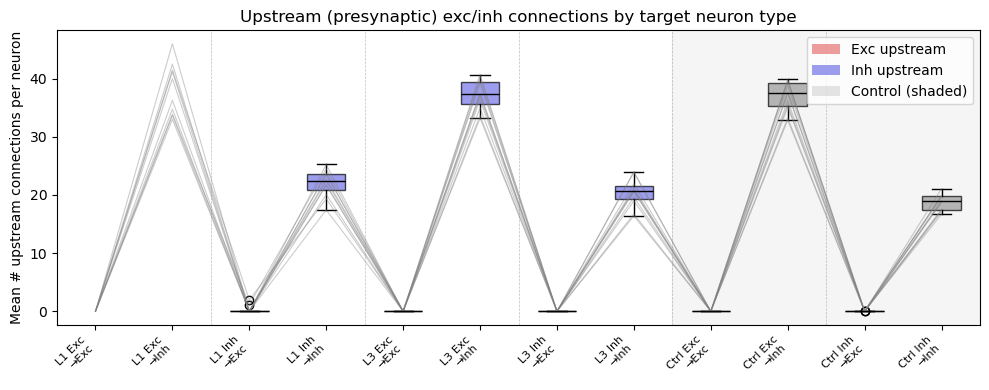

In [13]:
# Summary across models: mean upstream connection counts per group

means = {(g, t): [np.mean(presyn_counts[g][t][i]) if len(presyn_counts[g][t][i]) > 0 else np.nan
                  for i in range(len(model_names))]
         for g, t in group_keys}

plt.figure(figsize=(10, 4))
positions = np.arange(1, 13)
bp = plt.boxplot([means[(g, t)] for g, t in group_keys],
                 positions=positions, patch_artist=True,
                 medianprops=dict(color='black'))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# individual model lines
for i in range(len(model_names)):
    vals = [means[(g, t)][i] for g, t in group_keys]
    plt.plot(positions, vals, color='gray', alpha=0.4, linewidth=0.8)

for x in [2.5, 4.5, 6.5, 8.5, 10.5]:
    plt.axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvspan(8.5, 12.5, color='gray', alpha=0.08)

plt.xticks(positions, labels, rotation=45, ha='right', fontsize=8)
plt.ylabel('Mean # upstream connections per neuron')
plt.title('Upstream (presynaptic) exc/inh connections by target neuron type')

from matplotlib.patches import Patch
plt.legend(handles=[Patch(facecolor='#e87474', alpha=0.7, label='Exc upstream'),
                    Patch(facecolor='#7474e8', alpha=0.7, label='Inh upstream'),
                    Patch(facecolor='gray', alpha=0.2, label='Control (shaded)')],
           loc='upper right')
plt.tight_layout()
plt.show()

### downstream connections

In [14]:
# Downstream (postsynaptic) connections: for each target neuron n,
# count nonzero entries in W[exc_ind, n] and W[inh_ind, n] (column n = outgoing from n).
# W[a, b]: b -> a, so column b gives all neurons that b projects to.

postsyn_counts = {g: {'exc': [], 'inh': []} for g in ['l1_exc', 'l1_inh', 'l3_exc', 'l3_inh', 'ctrl_exc', 'ctrl_inh']}

for i, model_name in enumerate(model_names):
    model_dir = os.path.join(all_models_dir, model_name)

    tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num,
                                           other_labels='balance_stims',
                                           all_models_dir=all_models_dir)
    stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    W = ld.get_weights(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)

    load_tuned   = np.where(~np.isnan(tuning))[0]
    stim_untuned = np.where(np.isnan(stim1_tuning))[0]
    neuron_idxs  = np.intersect1d(load_tuned, stim_untuned)

    load1_idxs = neuron_idxs[tuning[neuron_idxs] == 1]
    load3_idxs = neuron_idxs[tuning[neuron_idxs] == 3]

    load1_exc_idxs = np.intersect1d(load1_idxs, exc_ind)
    load1_inh_idxs = np.intersect1d(load1_idxs, inh_ind)
    load3_exc_idxs = np.intersect1d(load3_idxs, exc_ind)
    load3_inh_idxs = np.intersect1d(load3_idxs, inh_ind)

    ctrl_idxs     = np.setdiff1d(stim_untuned, neuron_idxs)
    ctrl_exc_idxs = np.intersect1d(ctrl_idxs, exc_ind)
    ctrl_inh_idxs = np.intersect1d(ctrl_idxs, inh_ind)

    def count_downstream(target_idxs, W, dest_idxs):
        if len(target_idxs) == 0:
            return np.array([])
        # W[dest, target]: columns = target neurons, rows = destination neurons
        # sum over rows (axis=0) gives per-target count of downstream dest connections
        return np.sum(W[np.ix_(dest_idxs, target_idxs)] != 0, axis=0)

    for key, idxs in [('l1_exc', load1_exc_idxs), ('l1_inh', load1_inh_idxs),
                      ('l3_exc', load3_exc_idxs), ('l3_inh', load3_inh_idxs),
                      ('ctrl_exc', ctrl_exc_idxs), ('ctrl_inh', ctrl_inh_idxs)]:
        postsyn_counts[key]['exc'].append(count_downstream(idxs, W, exc_ind))
        postsyn_counts[key]['inh'].append(count_downstream(idxs, W, inh_ind))

    print(f'{model_name[-6:]}: '
          f'L1 exc({len(load1_exc_idxs)}) downstream exc={np.mean(count_downstream(load1_exc_idxs, W, exc_ind)):.1f} inh={np.mean(count_downstream(load1_exc_idxs, W, inh_ind)):.1f} | '
          f'L1 inh({len(load1_inh_idxs)}) downstream exc={np.mean(count_downstream(load1_inh_idxs, W, exc_ind)):.1f} inh={np.mean(count_downstream(load1_inh_idxs, W, inh_ind)):.1f} | '
          f'L3 exc({len(load3_exc_idxs)}) downstream exc={np.mean(count_downstream(load3_exc_idxs, W, exc_ind)):.1f} inh={np.mean(count_downstream(load3_exc_idxs, W, inh_ind)):.1f} | '
          f'L3 inh({len(load3_inh_idxs)}) downstream exc={np.mean(count_downstream(load3_inh_idxs, W, exc_ind)):.1f} inh={np.mean(count_downstream(load3_inh_idxs, W, inh_ind)):.1f}')

014901: L1 exc(8) downstream exc=0.0 inh=0.0 | L1 inh(19) downstream exc=156.8 inh=18.9 | L3 exc(168) downstream exc=0.0 inh=0.0 | L3 inh(13) downstream exc=147.0 inh=21.0


/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


034721: L1 exc(0) downstream exc=nan inh=nan | L1 inh(18) downstream exc=150.1 inh=21.8 | L3 exc(96) downstream exc=0.0 inh=0.0 | L3 inh(11) downstream exc=140.5 inh=22.6
031000: L1 exc(2) downstream exc=0.0 inh=0.0 | L1 inh(12) downstream exc=150.8 inh=17.7 | L3 exc(142) downstream exc=0.0 inh=0.0 | L3 inh(18) downstream exc=138.7 inh=19.9
041152: L1 exc(2) downstream exc=0.0 inh=0.0 | L1 inh(19) downstream exc=153.9 inh=21.8 | L3 exc(220) downstream exc=0.0 inh=0.0 | L3 inh(18) downstream exc=138.7 inh=18.6
180002: L1 exc(11) downstream exc=0.0 inh=0.0 | L1 inh(12) downstream exc=147.9 inh=20.0 | L3 exc(154) downstream exc=0.0 inh=0.0 | L3 inh(10) downstream exc=139.0 inh=14.2
233744: L1 exc(9) downstream exc=0.0 inh=0.0 | L1 inh(17) downstream exc=149.1 inh=22.6 | L3 exc(118) downstream exc=0.0 inh=0.0 | L3 inh(17) downstream exc=142.4 inh=20.2
023239: L1 exc(17) downstream exc=0.0 inh=0.1 | L1 inh(12) downstream exc=159.2 inh=18.5 | L3 exc(134) downstream exc=0.0 inh=0.0 | L3 inh(1

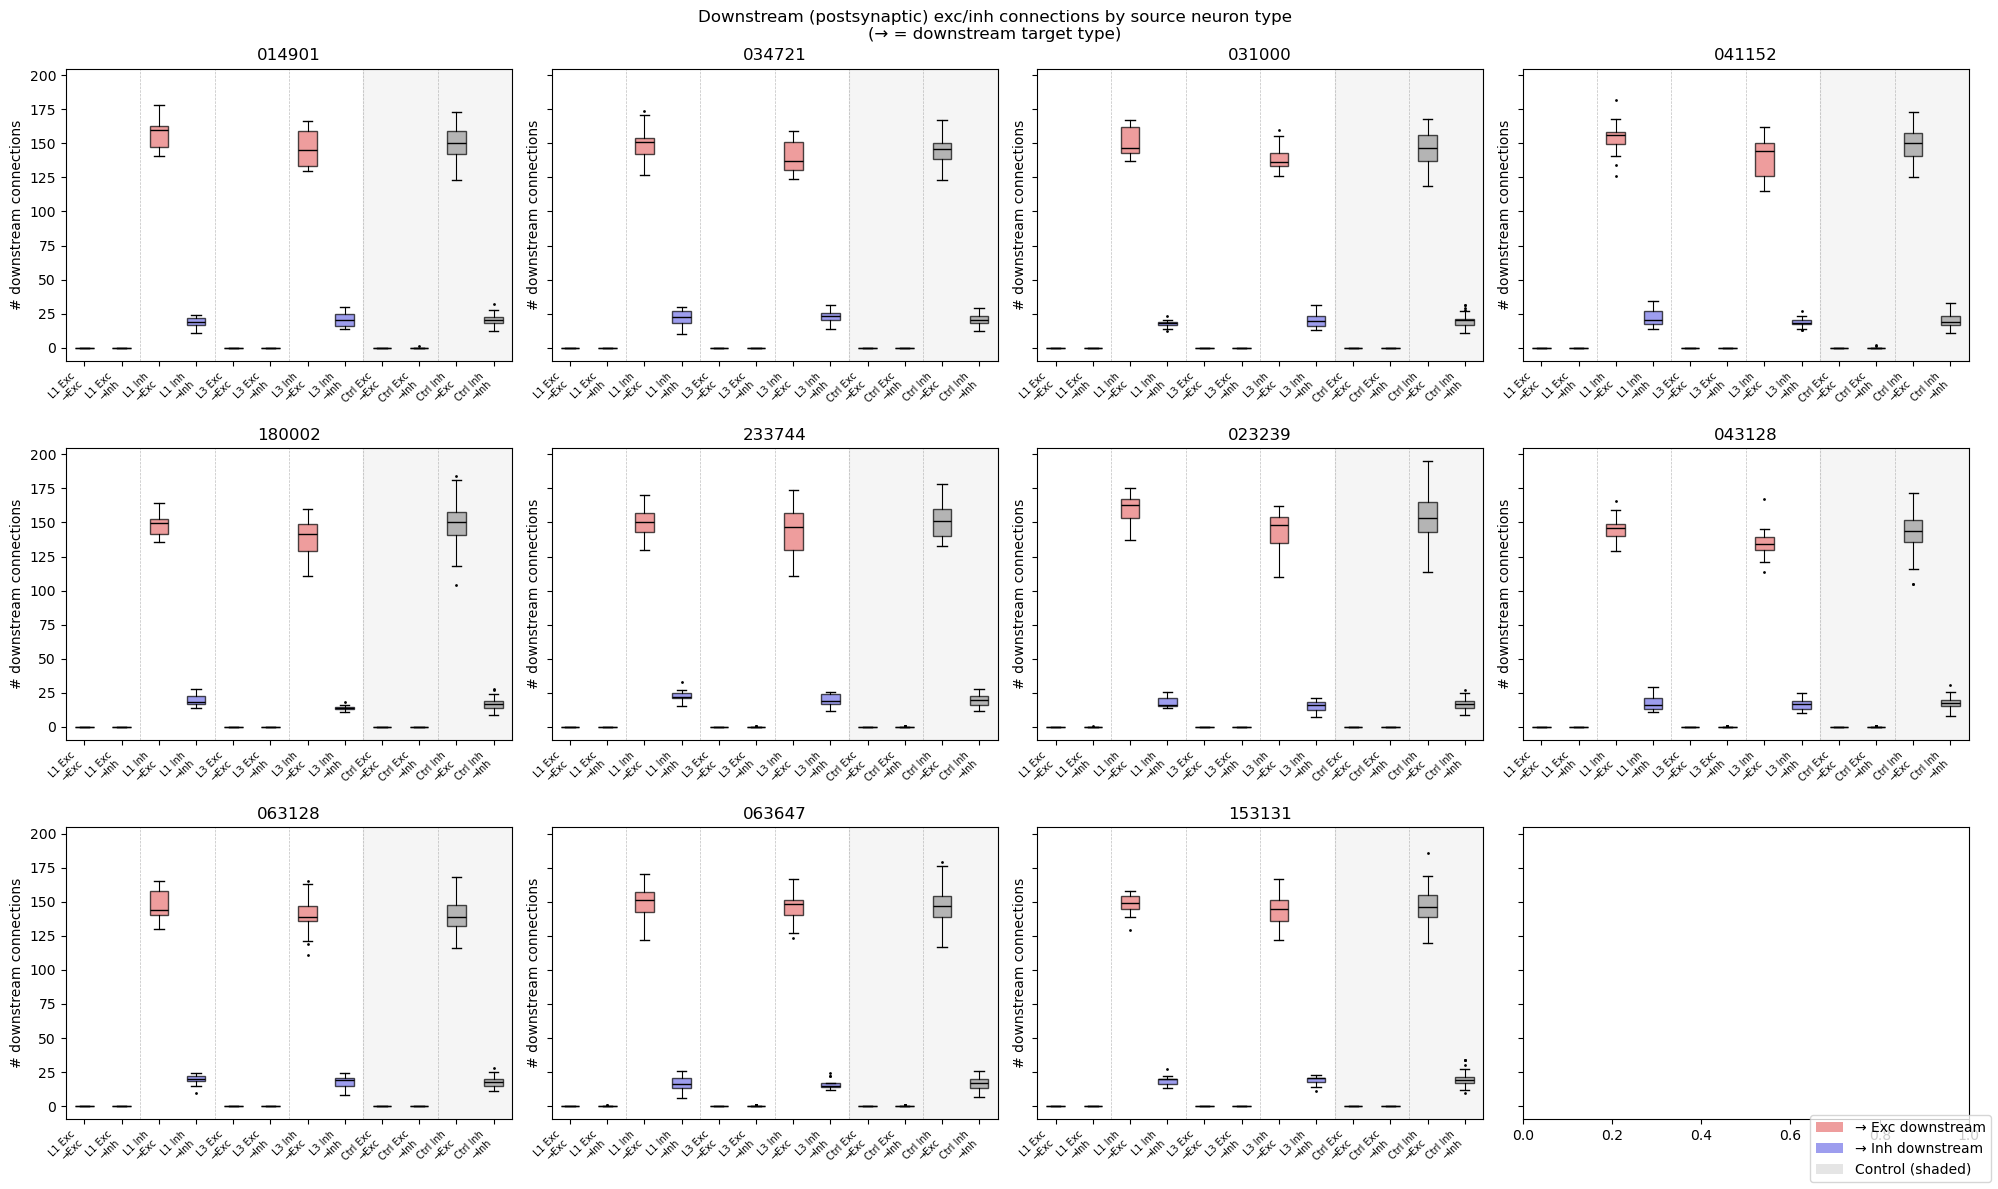

In [17]:
# Per-model boxplots: downstream exc/inh connections, split by source neuron type

fig, axs = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
axs = axs.flatten()

for i, model_name in enumerate(model_names):
    data = [postsyn_counts[g][t][i] for g, t in group_keys]
    plot_data = [d if len(d) > 0 else np.array([0]) for d in data]

    bp = axs[i].boxplot(plot_data, positions=np.arange(1, 13), patch_artist=True,
                        medianprops=dict(color='black'), whiskerprops=dict(linewidth=0.8),
                        flierprops=dict(marker='.', markersize=2))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for x in [2.5, 4.5, 6.5, 8.5, 10.5]:
        axs[i].axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    axs[i].axvspan(8.5, 12.5, color='gray', alpha=0.08)

    axs[i].set_xticks(np.arange(1, 13))
    axs[i].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    axs[i].set_ylabel('# downstream connections')
    axs[i].set_title(f'{model_name[-6:]}')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e87474', alpha=0.7, label='→ Exc downstream'),
                   Patch(facecolor='#7474e8', alpha=0.7, label='→ Inh downstream'),
                   Patch(facecolor='gray',    alpha=0.2, label='Control (shaded)')]
fig.legend(handles=legend_elements, loc='lower right')
plt.suptitle('Downstream (postsynaptic) exc/inh connections by source neuron type\n(→ = downstream target type)')
plt.tight_layout()
plt.show()

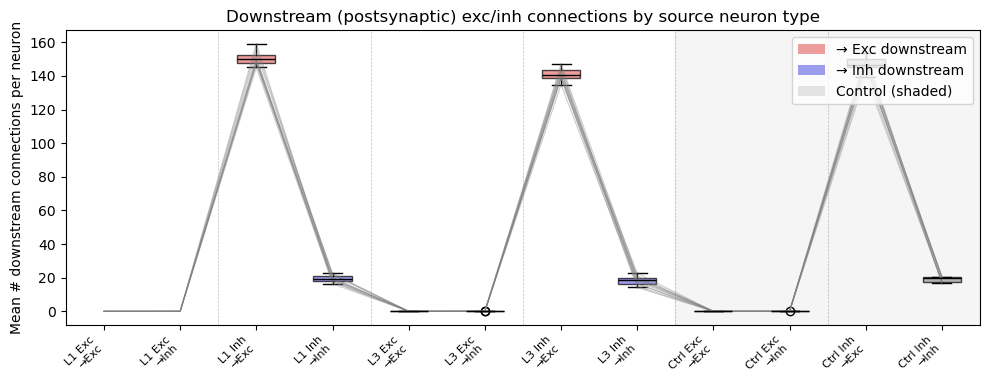

In [16]:
# Summary across models: mean downstream connection counts per group

postsyn_means = {(g, t): [np.mean(postsyn_counts[g][t][i]) if len(postsyn_counts[g][t][i]) > 0 else np.nan
                           for i in range(len(model_names))]
                 for g, t in group_keys}

plt.figure(figsize=(10, 4))
bp = plt.boxplot([postsyn_means[(g, t)] for g, t in group_keys],
                 positions=positions, patch_artist=True,
                 medianprops=dict(color='black'))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i in range(len(model_names)):
    vals = [postsyn_means[(g, t)][i] for g, t in group_keys]
    plt.plot(positions, vals, color='gray', alpha=0.4, linewidth=0.8)

for x in [2.5, 4.5, 6.5, 8.5, 10.5]:
    plt.axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvspan(8.5, 12.5, color='gray', alpha=0.08)

plt.xticks(positions, labels, rotation=45, ha='right', fontsize=8)
plt.ylabel('Mean # downstream connections per neuron')
plt.title('Downstream (postsynaptic) exc/inh connections by source neuron type')

from matplotlib.patches import Patch
plt.legend(handles=[Patch(facecolor='#e87474', alpha=0.7, label='→ Exc downstream'),
                    Patch(facecolor='#7474e8', alpha=0.7, label='→ Inh downstream'),
                    Patch(facecolor='gray', alpha=0.2, label='Control (shaded)')],
           loc='upper right')
plt.tight_layout()
plt.show()

## check firing rates